Imports

In [4]:
import pandas as pd                               # for loading and manipulating our DataFrame
import nltk                                       # Natural Language Toolkit — stopwords
import re                                         # regular expressions — for cleaning text patterns
import matplotlib.pyplot as plt                   # for plotting preprocessing comparison figures
import seaborn as sns                             # for prettier statistical plots
from nltk.corpus import stopwords                 # pre-built list of common words to remove
from nltk import word_tokenize, pos_tag           # tokenizer and POS tagger from NLTK
from nltk.stem import WordNetLemmatizer           # lemmatizer — reduces words to base form
from collections import Counter                   # for counting word frequencies efficiently
from pathlib import Path                          # for handling file paths in a platform-independent way

Download NLTK data

In [2]:
# Download all NLTK data packages we need — run once
nltk.download('stopwords')                        # English stopwords list
nltk.download('punkt')                            # tokenizer rules
nltk.download('punkt_tab')                        # updated tokenizer data for NLTK 3.9+
nltk.download('averaged_perceptron_tagger')       # POS tagger (part-of-speech tagging)
nltk.download('averaged_perceptron_tagger_eng')   # English-specific POS tagger data
nltk.download('wordnet')                          # WordNet lexical database for lemmatization

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/daniel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/daniel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/daniel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/daniel/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/daniel/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /Users/daniel/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Load Data

In [16]:
from pathlib import Path
import pandas as pd

processed_dir = Path("../data/processed/Eng-NA")

# Read from _final/ — already filtered to Target_Child, clean column names
parquet_files = sorted((processed_dir / "_final").rglob("*.parquet"))
print(f"Parquet files found: {len(parquet_files)}")
for f in parquet_files:
    print(" -", f)

dfs = []
for f in parquet_files:
    tmp = pd.read_parquet(f)
    tmp["source_file"] = f.name
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

# Rename to standard names used throughout the notebook
df = df.rename(columns={
    "subj_id": "child_id",
    "age_mo":  "age_months",
})

# 'clean' is already a plain string — use it directly as text input
df["text"] = df["clean"].fillna("").astype(str)

df = df.reset_index(drop=True)

print(f"\nSessions loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(df[["child_id", "age_months", "mlu", "ttr", "text"]].head(3))


Parquet files found: 1
 - ../data/processed/Eng-NA/_final/Brown.parquet

Sessions loaded: 200
Columns: ['sess_id', 'child_id', 'lang', 'exp', 'age_months', 'raw', 'clean', 'clean_impt', 'clean_punct', 'behav', 'mlu', 'mlu_w', 'mlu_m', 'ttr', 'ipsyn', 'n_utt', 'env_mlu', 'env_n_utt', 'env_ratio', 'prev_utt', 'next_utt', 'env_clean', 'env_behav', 'pos_seq', 'pos_var', 'pos_uniq', 'morph_seq', 'morph_var', 'morph_uniq', 'gra_seq', 'gra_var', 'gra_uniq', 'dep_seq', 'dep_var', 'dep_uniq', 'pho_seq', 'pho_var', 'pho_uniq', 'n_unint', 'n_omiss', 'n_err', 'n_frag', 'n_fill', 'n_pause', 'n_ev', 'n_rep', 'n_ret', 'n_ref', 'n_int', 'n_ov', 'n_imit', 'n_res', 'meta_comments', 'meta_date', 'meta_lang', 'meta_loc', 'meta_media', 'meta_num', 'meta_opt', 'meta_misc', 'meta_parts', 'meta_pid', 'meta_rec_qual', 'meta_room', 'meta_sit', 'meta_tape_loc', 'meta_duration', 'meta_time_start', 'meta_staff', 'meta_trans_type', 'meta_types', 'meta_videos', 'meta_warning', 'source_file', 'text']
  child_id  age_

In [17]:
# Pick one session and inspect the raw text carefully before touching it
sample_text = df['text'].iloc[0]                  # grab the first session's text

print("RAW TEXT (first 500 chars):")
print(sample_text[:500])                          # show first 500 characters

print(f"\nTotal tokens (raw): {len(sample_text.split())}")  # count words by splitting on spaces
print(f"Unique tokens (raw): {len(set(sample_text.split()))}")  # count unique words

RAW TEXT (first 500 chars):
more cookie more cookie more juice fraser fraser fraser fraser yeah th at a fly gestures fly mommy telephone my telephone mommy no man man more cookie block broke there i did it there there fraser baby mommy read a stool fraser fraser more cookie more cookie little little little little milk milk milk milk that fraser water oh fraser bye water fraser water fraser water that coffee fraser coffee down down whispering cookie mommy mommy a fly gestures read the puzzle read the puzzle read the puzzle 

Total tokens (raw): 2249
Unique tokens (raw): 336


In [18]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return 'a'
    elif tag.startswith('V'): return 'v'
    elif tag.startswith('N'): return 'n'
    elif tag.startswith('R'): return 'r'
    else: return 'n'

def is_proper_noun(token):
    # Drop tokens like "Flopsy", "Adam" (capital + lowercase letters)
    # Keep tokens like "US", "TV", "OK" (all caps or single caps)
    return bool(re.match(r'^[A-Z][a-z]', token))

def preprocess_02b(text, lemmatize=True):
    # Step 1: tokenize on ORIGINAL casing (needed to detect proper nouns)
    tokens = word_tokenize(str(text))

    # Step 2: drop proper nouns (child names, toy names, circumstantial words)
    tokens = [t for t in tokens if not is_proper_noun(t)]

    # Step 3: lowercase what survived
    tokens = [t.lower() for t in tokens]

    # Step 4: lemmatize (optional)
    if lemmatize:
        pos_tags = pos_tag(tokens)
        tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(tag)) for w, tag in pos_tags]

    return " ".join(tokens)

In [19]:
# Lemmatized version (main)
df['text_lemma'] = df['text'].apply(
    lambda x: preprocess_02b(x, lemmatize=True)
)

# Non-lemmatized version (to isolate lemmatization impact)
df['text_no_lemma'] = df['text'].apply(
    lambda x: preprocess_02b(x, lemmatize=False)
)

print("Preprocessing applied.")
print(df[['child_id', 'age_months', 'text_lemma']].head(3))

Preprocessing applied.
  child_id  age_months                                         text_lemma
0      Eve        18.0  more cookie more cookie more juice fraser fras...
1      Eve        19.0  more coffee more grape juice too no oh frasers...
2      Eve        20.0  more grape juice no no eve play bouillon cube ...


In [20]:
print("=== BEFORE (raw text) ===")
print(df['text'].iloc[0][:300])

print("\n=== AFTER: Proper nouns removed + lemmatized ===")
print(df['text_lemma'].iloc[0][:300])

print("\n=== AFTER: Proper nouns removed, NO lemmatization ===")
print(df['text_no_lemma'].iloc[0][:300])

=== BEFORE (raw text) ===
more cookie more cookie more juice fraser fraser fraser fraser yeah th at a fly gestures fly mommy telephone my telephone mommy no man man more cookie block broke there i did it there there fraser baby mommy read a stool fraser fraser more cookie more cookie little little little little milk milk mil

=== AFTER: Proper nouns removed + lemmatized ===
more cookie more cookie more juice fraser fraser fraser fraser yeah th at a fly gesture fly mommy telephone my telephone mommy no man man more cookie block break there i do it there there fraser baby mommy read a stool fraser fraser more cookie more cookie little little little little milk milk milk 

=== AFTER: Proper nouns removed, NO lemmatization ===
more cookie more cookie more juice fraser fraser fraser fraser yeah th at a fly gestures fly mommy telephone my telephone mommy no man man more cookie block broke there i did it there there fraser baby mommy read a stool fraser fraser more cookie more cookie little l

In [21]:
df['n_raw']      = df['text'].apply(lambda x: len(str(x).split()))
df['n_lemma']    = df['text_lemma'].apply(lambda x: len(x.split()))
df['n_no_lemma'] = df['text_no_lemma'].apply(lambda x: len(x.split()))

print("Average tokens per session:")
print(f"  Raw:          {df['n_raw'].mean():.1f}")
print(f"  Lemmatized:   {df['n_lemma'].mean():.1f}")
print(f"  No lemma:     {df['n_no_lemma'].mean():.1f}")

Average tokens per session:
  Raw:          1611.7
  Lemmatized:   1620.7
  No lemma:     1620.7


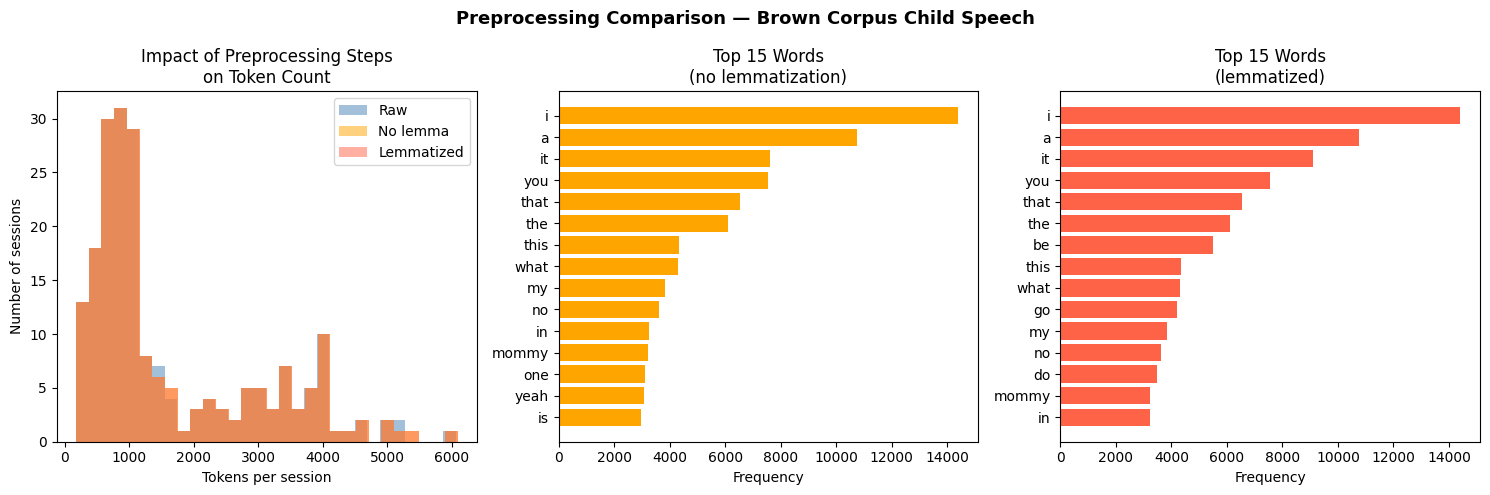

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: Token count distribution — lemmatized vs no lemma vs raw ---
axes[0].hist(df['n_raw'],      bins=30, alpha=0.5,
             label='Raw', color='steelblue')
axes[0].hist(df['n_no_lemma'], bins=30, alpha=0.5,
             label='No lemma', color='orange')
axes[0].hist(df['n_lemma'],    bins=30, alpha=0.5,
             label='Lemmatized', color='tomato')
axes[0].set_xlabel('Tokens per session')
axes[0].set_ylabel('Number of sessions')
axes[0].set_title('Impact of Preprocessing Steps\non Token Count')
axes[0].legend()

# --- Plot 2: Top 15 words — no lemmatization ---
all_words_no_lemma = " ".join(df['text_no_lemma']).split()
top_no_lemma = Counter(all_words_no_lemma).most_common(15)
words_nl, counts_nl = zip(*top_no_lemma)
axes[1].barh(words_nl, counts_nl, color='orange')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Words\n(no lemmatization)')
axes[1].set_xlabel('Frequency')

# --- Plot 3: Top 15 words — lemmatized ---
all_words_lemma = " ".join(df['text_lemma']).split()
top_lemma = Counter(all_words_lemma).most_common(15)
words_l, counts_l = zip(*top_lemma)
axes[2].barh(words_l, counts_l, color='tomato')
axes[2].invert_yaxis()
axes[2].set_title('Top 15 Words\n(lemmatized)')
axes[2].set_xlabel('Frequency')

plt.suptitle('Preprocessing Comparison — Brown Corpus Child Speech',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/preprocessing_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [24]:
df.to_csv("../data/processed/sessions_clean_02b.csv", index=False)
print(f"Saved {len(df)} sessions → ../data/processed/sessions_clean_02b.csv")
print(f"Columns: {list(df.columns)}")

Saved 200 sessions → ../data/processed/sessions_clean_02b.csv
Columns: ['sess_id', 'child_id', 'lang', 'exp', 'age_months', 'raw', 'clean', 'clean_impt', 'clean_punct', 'behav', 'mlu', 'mlu_w', 'mlu_m', 'ttr', 'ipsyn', 'n_utt', 'env_mlu', 'env_n_utt', 'env_ratio', 'prev_utt', 'next_utt', 'env_clean', 'env_behav', 'pos_seq', 'pos_var', 'pos_uniq', 'morph_seq', 'morph_var', 'morph_uniq', 'gra_seq', 'gra_var', 'gra_uniq', 'dep_seq', 'dep_var', 'dep_uniq', 'pho_seq', 'pho_var', 'pho_uniq', 'n_unint', 'n_omiss', 'n_err', 'n_frag', 'n_fill', 'n_pause', 'n_ev', 'n_rep', 'n_ret', 'n_ref', 'n_int', 'n_ov', 'n_imit', 'n_res', 'meta_comments', 'meta_date', 'meta_lang', 'meta_loc', 'meta_media', 'meta_num', 'meta_opt', 'meta_misc', 'meta_parts', 'meta_pid', 'meta_rec_qual', 'meta_room', 'meta_sit', 'meta_tape_loc', 'meta_duration', 'meta_time_start', 'meta_staff', 'meta_trans_type', 'meta_types', 'meta_videos', 'meta_warning', 'source_file', 'text', 'text_lemma', 'text_no_lemma', 'n_raw', 'n_lemma

Plot 1 — Token Count Distribution
The three histograms are almost perfectly overlapping for "No lemma" (orange) and "Full pipeline" (red). This tells us something important:
Lemmatization barely changes token count — it doesn't remove words, it just changes their form ("checkers" → "checker", "running" → "run"). So the orange and red bars sit almost on top of each other.
Stopword removal has the big visible impact — the blue distribution (stops kept) is shifted right, meaning sessions have many more tokens when stopwords are kept. That 43% reduction we saw numerically is visible here.

Plot 2 vs Plot 3 — Top 15 Words:

With stopwords: The top words are grammatical fillers — completely uninformative for developmental analysis. A 2-year-old and a 5-year-old both say "it" and "you" constantly.
Full pipeline: The top words are content words with developmental meaning — mommy, go, see, want, make. These are exactly the words that should differentiate early vs late speech. This is what we want feeding into our DTM.

We Keep Lemmatization, because lemmatization matters more at the DTM/TF-IDF stage than at the token count stage. Without it:

"go", "goes", "going", "went" would be 4 separate columns into the DTM
With it: all collapse into "go" — one column, stronger signal

For child speech specifically this matters even more — young children produce lots of irregular inflections ("goed" instead of "went", "mouses" instead of "mice"). Lemmatization normalizes all of that.